# Crystal Structure Optimization Using PED Patterns #

In this tutorial, we optimize the crystal structure parameters of TiO₂ using its precession electron diffraction (PED) pattern.

## 0. Preparation: Experimental Data for Optimization ##

First, prepare the experimental data to be used for optimization. Here, we provide sample data obtained by simulating the PED pattern using a TiO₂ CIF file. In this tutorial, we will use the simulation results to perform parameter optimization of the crystal structure and confirm that the original CIF structure can be reproduced.

## 1. Creating the Crystal Structure for Optimization ##

Create a parametrized crystal structure from the CIF file. For details, refer to the [lys_mat tutorial](https://a-tock.github.io/lys_mat/tutorial.html).

In [1]:
from lys_mat import CrystalStructure
crys_raw = CrystalStructure.loadFrom("data/TiO2.cif")
print(crys_raw)

Symmetry: tetragonal P4_2/mnm (No. 136), Point group: 4/mmm
a = 4.59400, b = 4.59400, c = 2.95860, alpha = 90.00000, beta = 90.00000, gamma = 90.00000
--- atoms (6) ---
1: O (Z = 8, Occupancy = 1) Pos = (0.30495, 0.30495, 0.00000)
2: O (Z = 8, Occupancy = 1) Pos = (0.69505, 0.69505, 0.00000)
3: O (Z = 8, Occupancy = 1) Pos = (0.19505, 0.80495, 0.50000)
4: O (Z = 8, Occupancy = 1) Pos = (0.80495, 0.19505, 0.50000)
5: Ti (Z = 22, Occupancy = 1) Pos = (0.00000, 0.00000, 0.00000)
6: Ti (Z = 22, Occupancy = 1) Pos = (0.50000, 0.50000, 0.50000)


In [2]:
crys = crys_raw.createParametrizedCrystal()
crys = crys.subs({key: value for key, value in crys.defaultParameters.items() if key != "y_O4"})
print(crys)

Failed to find symmetry
a = 4.59400, b = 4.59400, c = 2.95860, alpha = 90.00000, beta = 90.00000, gamma = 90.00000
--- atoms (6) ---
1: O (Z = 8, Occupancy = 1) Pos = (1/2 - y_O4, 1/2 - y_O4, 0.0)
2: O (Z = 8, Occupancy = 1) Pos = (y_O4 + 1/2, y_O4 + 1/2, 0.0)
3: O (Z = 8, Occupancy = 1) Pos = (y_O4, 1 - y_O4, 0.5)
4: O (Z = 8, Occupancy = 1) Pos = (1 - y_O4, y_O4, 0.5)
5: Ti (Z = 22, Occupancy = 1) Pos = (0.00000, 0.00000, 0.00000)
6: Ti (Z = 22, Occupancy = 1) Pos = (0.50000, 0.50000, 0.50000)


In this tutorial, we optimize the parameter *y_O4* and verify that it converges to approximately 0.195.

## 2. Setting Parameters for PED Simulation ##

Define the computational space, crystal potential, and TEM parameters for the PED simulation.

In [3]:
import numpy as np
from lys_em import FunctionSpace, CrystalPotential, TEM, TEMParameter
spc = FunctionSpace.fromCrystal(crys, Nx=128, Ny=128, ncells=50)
pot = CrystalPotential(spc, crys)
tem = TEM(60e3, params=[TEMParameter(tilt=[2, phi]) for phi in np.arange(0, 360, 360 / 30)])

## 3. Defining the Forward Calculation ##

Define a function that performs the forward calculation for the precession diffraction.

In [4]:
from lys_em import multislice
def calc_intensity(param):
    pot_subs = pot.replace(params=param)    # Create a new CrystalPotential using the given parameter values
    return multislice(pot_subs, tem, postprocess="diffraction", sum=True).real

## 4. Loading the Experimental Data ##

Load the experimental data prepared in step 0.

In [5]:
data = np.load("data/TiO2_PED_data.npy")
indices = np.load("data/TiO2_PED_indices.npy")

*data* contains the PED intensities and indices contains the indices of diffraction spots used for optimization.

In [6]:
print("data.shape: ", data.shape)
print("indices.shape: ", indices.shape)
print("indices: ")
print(indices[:10])

data.shape:  (100,)
indices.shape:  (100, 3)
indices: 
[[ 0  0  0]
 [ 0  1  0]
 [ 0 -1  0]
 [ 1  0  0]
 [-1  0  0]
 [ 1  1  0]
 [ 1 -1  0]
 [-1  1  0]
 [-1 -1  0]
 [ 0  2  0]]


We can visualize the data using matplotlib.

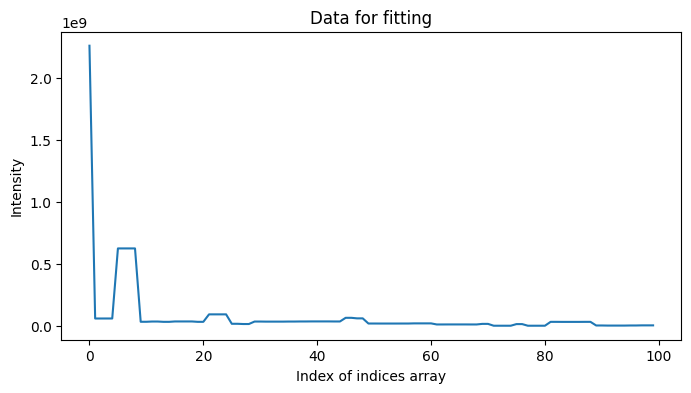

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(data)
plt.xlabel("Index of indices array")
plt.ylabel("Intensity")
plt.title("Data for fitting")
plt.show()

## 5. Defining the Residual Function ##

Define the residual function used for optimization.

In [8]:
import jax.numpy as jnp
def residual(values):
    calc = calc_intensity({name: value for name, value in zip(crys.free_symbols, values)})      # Forward calculation
    calc_arr = jnp.array([calc[int(indice[0]), int(indice[1])] for indice in indices])          # Extract calculated intensities
    scale = jnp.sum(data * calc_arr) / jnp.sum(calc_arr**2)                                     # Calculate scaling factor
    R = jnp.linalg.norm(data - scale * calc_arr, ord=1) / jnp.linalg.norm(data, ord=1)          # Calculate residual
    return jnp.array(R)

## 6. Running the Optimization ##

Set the initial value and parameter bounds, and perform optimization.

In [9]:
import jax
import scipy.optimize as optimize
initial = [0.15]        # Initial guess
bounds = [(0, 0.25)]    # Parameter bounds
res = optimize.minimize(residual, initial, bounds=bounds, jac=jax.grad(residual), tol=7e-2)
print("y_O4 :", f"{res.x[0]:.6f}")

y_O4 : 0.195060


The result confirms that y_O4 ≈ 0.195, close to the value in the CIF file.

## Summary ##

Complete code for performing the optimization.

In [10]:
import numpy as np
import jax
import jax.numpy as jnp
import scipy.optimize as optimize
from lys_mat import CrystalStructure
from lys_em import FunctionSpace, CrystalPotential, TEM, TEMParameter, multislice

# Create crystal structure
crys_raw = CrystalStructure.loadFrom("data/TiO2.cif")
crys = crys_raw.createParametrizedCrystal()
crys = crys.subs({key: value for key, value in crys.defaultParameters.items() if key != "y_O4"})

# Set simulation parameters
spc = FunctionSpace.fromCrystal(crys, Nx=128, Ny=128, ncells=50)
pot = CrystalPotential(spc, crys)
tem = TEM(60e3, params=[TEMParameter(tilt=[2, phi]) for phi in np.arange(0, 360, 360 / 30)])

# Define forward calculation
def calc_intensity(param):
    pot_subs = pot.replace(params=param)
    return multislice(pot_subs, tem, postprocess="diffraction", sum=True)

# Load experimental data
data = np.load("data/TiO2_PED_data.npy")
indices = np.load("data/TiO2_PED_indices.npy")

# Define residual function
def residual(values):
    calc = calc_intensity({name: value for name, value in zip(crys.free_symbols, values)})
    calc_arr = jnp.array([calc[int(indice[0]), int(indice[1])] for indice in indices])
    scale = jnp.sum(data * calc_arr) / jnp.sum(calc_arr**2)
    R = jnp.linalg.norm(data - scale * calc_arr, ord=1) / jnp.linalg.norm(data, ord=1)
    return jnp.array(R)

# Run optimization
res = optimize.minimize(residual, [0.15], bounds=[(0, 0.25)], jac=jax.grad(residual), tol=7e-2)
print("y_O4 :", f"{res.x[0]:.6f}")

y_O4 : 0.195060
